ARTICLE NOTES TO TEST

- We observed a significant drop of the 1st order textural features “10th percentile” (p = 0.009), “median” (p = 0.01), and “minimum” (p <0.0001) after treatment
- &#9989; All parameters were tested for the normality by Kolmogorov–Smirnov test and Shapiro–Wilk test
- ❌ A Wilcoxon test was used to test the difference in textural features before and after treatment
- To address the multiple comparisons, a Benjamin Hochberg correction was applied
- We applied a z-transformation on all textural features to enable comparability of textural feature values

In [44]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro, kstest, wilcoxon
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [8]:
df = pd.read_csv(r"D:\CSV\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
df.head()

features_df = df.iloc[:, 1:]
features_df.head()

,n_lesions,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,...,gradient_gldm_LargeDependenceLowGrayLevelEmphasis,gradient_gldm_LowGrayLevelEmphasis,gradient_gldm_SmallDependenceEmphasis,gradient_gldm_SmallDependenceHighGrayLevelEmphasis,gradient_gldm_SmallDependenceLowGrayLevelEmphasis,gradient_ngtdm_Busyness,gradient_ngtdm_Coarseness,gradient_ngtdm_Complexity,gradient_ngtdm_Contrast,gradient_ngtdm_Strength
0,42,0.208989,0.090847,48.159211,530.112286,489.628282,477.609470,70.013470,524.164765,3558.334557,...,9.362924,0.188559,0.209187,14.160098,0.022200,4.583890,0.001057,1275.015695,0.027065,2.332194
1,26,0.312599,0.177995,56.369710,316.692125,312.249080,221.602910,62.017486,350.835395,9249.070315,...,28.594575,0.281659,0.126935,5.482893,0.015539,30.713151,0.000442,227.679082,0.031244,0.178511
2,8,0.212942,0.151533,36.779604,242.716318,120.025001,223.923365,26.654969,272.485527,1064.250852,...,9.860269,0.186676,0.205416,17.281903,0.019481,1.752884,0.003683,862.559969,0.048362,4.607406
3,54,0.159429,0.086400,43.732812,506.164698,448.831706,452.620461,83.059497,506.059601,29295.494225,...,34.494715,0.317299,0.156313,11.428918,0.015238,50.791713,0.000115,1226.057056,0.020648,0.360999
4,12,0.192710,0.149551,57.235029,382.711335,214.831665,320.170141,47.350217,373.626743,3274.072115,...,10.018471,0.174378,0.192016,16.347327,0.018704,7.015196,0.000999,731.506812,0.049377,1.028209


All parameters were tested for the normality by Kolmogorov–Smirnov test and Shapiro–Wilk test

In [13]:
# NORMALITY SHAPIRO-WILK
def split_by_normality(df):
    normal_features = []
    non_normal_features = []

    numeric_cols = df.select_dtypes(include='number').columns

    for col in numeric_cols:
        if df[col].dropna().shape[0] < 3:
            continue

        stat, p_val = shapiro(df[col].dropna())
        if p_val > 0.05:
            normal_features.append(col)
        else:
            non_normal_features.append(col)

    return normal_features, non_normal_features

normal_features_sw, non_normal_features_sw = split_by_normality(features_df)

print("-----SHAPIRO WILK TEST-----")
print("Normal features:", len(normal_features_sw))
print("Non-normal features:", len(non_normal_features_sw))
print()


# NORMALITY KOLMOGOROV-SMIRN
def split_by_ks_normality(features_df):
    normal_features = []
    non_normal_features = []

    numeric_cols = features_df.select_dtypes(include='number').columns

    for col in numeric_cols:
        data = features_df[col].dropna()
        if len(data) < 3:
            continue

        stat, p_val = kstest(data, 'norm', args=(data.mean(), data.std()))

        if p_val > 0.05:
            normal_features.append(col)
        else:
            non_normal_features.append(col)

    return normal_features, non_normal_features

normal_features_kw, non_normal_features_kw = split_by_ks_normality(features_df)

print("-----KOLMOGOROV WILK TEST-----")
print("Normal features:", len(normal_features_kw))
print("Non-normal features:", len(non_normal_features_kw))

-----SHAPIRO WILK TEST-----
Normal features: 71
Non-normal features: 130

-----KOLMOGOROV WILK TEST-----
Normal features: 152
Non-normal features: 49


Correlation analysis of image features

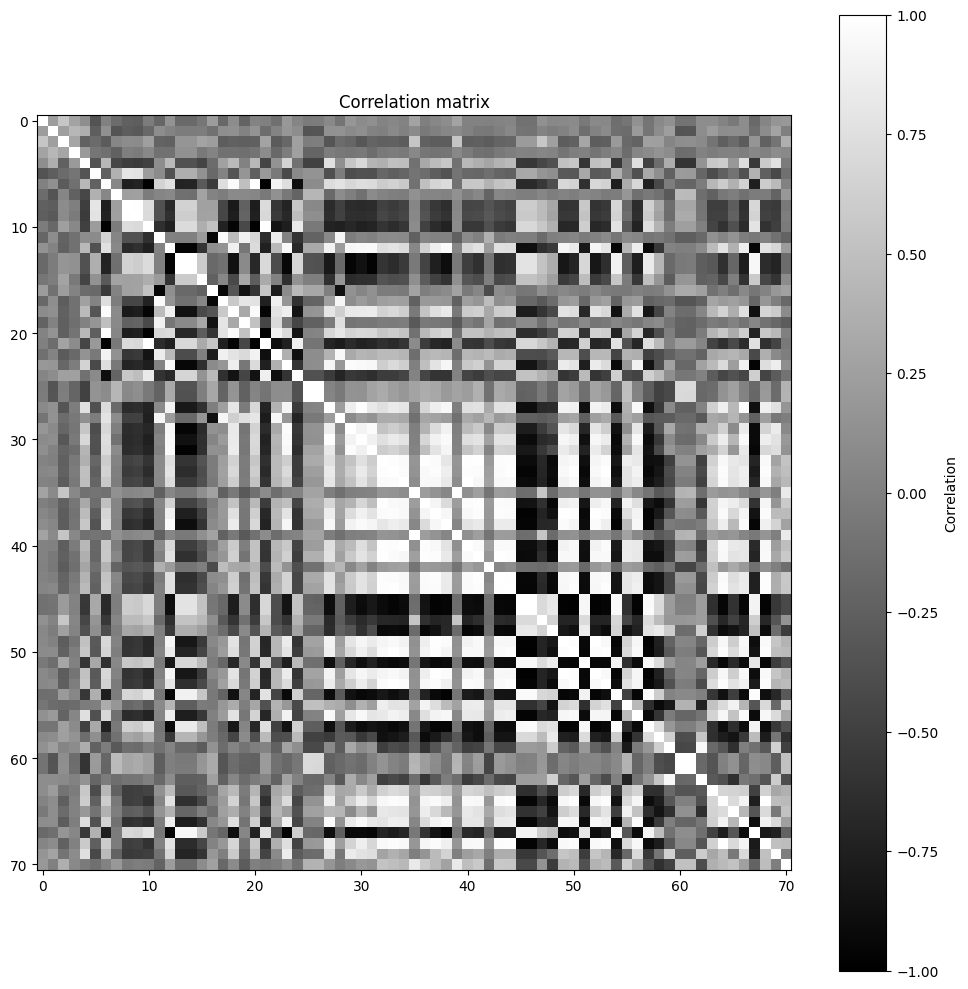

In [29]:
scaler = StandardScaler()
features = normal_features_sw   # normal_features_sw/non_normal_features_sw   normal_features_kw/non_normal_features_kw
method = "pearson"   # pearson/spearman/kendall

features_scaled = pd.DataFrame(scaler.fit_transform(features_df[features]), columns=features_df[features].columns, index=features_df[features].index)
corr_matrix = features_scaled.corr(method=method)

plt.figure(figsize=(10,10))
plt.imshow(corr_matrix, cmap='gray', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

❌ A Wilcoxon test was used to test the difference in textural features before and after treatment

- Can't be used on spine level (I need more values of same feature)
- Can't be used also on vertebrae or lesions level, because after treatment there is a drop in number of lesions and also drop of some rows (arrays have to be equal)
- Solution -> pick one image, compute first order features for all vertebrae (healthy and also lesions together), than compare.

In [62]:
# COMPARISON OF DIFFERENCES BEFORE AND AFTER TREATMENT
before_treatment = pd.read_csv(r"D:\DATA_Myelomy\Myel_012\CaSupp_25_radiomics_spine_lesions_features.csv")
after_treatment = pd.read_csv(r"D:\DATA_Myelomy\Myel_069\CaSupp_25_radiomics_spine_lesions_features.csv")

diff = (before_treatment.iloc[0] - after_treatment.iloc[0]).abs()
diff_df = pd.DataFrame({"feature": diff.index, "difference": diff.values})
diff_df = diff_df.sort_values(by="difference", ascending=False).reset_index(drop=True)
# diff_df.head(20)
diff_df

,feature,difference
0,original_firstorder_Energy,3.125586e+07
1,original_firstorder_TotalEnergy,1.790038e+07
2,gradient_firstorder_Energy,1.153664e+06
3,gradient_firstorder_TotalEnergy,6.626612e+05
4,original_glszm_LargeAreaHighGrayLevelEmphasis,1.762952e+05
...,...,...
196,original_ngtdm_Coarseness,8.842529e-04
197,original_glrlm_ShortRunLowGrayLevelEmphasis,8.094871e-04
198,gradient_ngtdm_Coarseness,5.371391e-04
199,original_gldm_SmallDependenceLowGrayLevelEmphasis,1.972321e-04
